# R2.03 - Sensitivity del Clustering alla Finestra DOY

Questo notebook esegue solo:
1. preprocessing ERA5 con diverse finestre della media mobile per giorno dell'anno (DOY),
2. clustering stagionale,
3. confronto dei risultati (error history, silhouette, breakpoints).

CMIP6 e training del perceptron non vengono eseguiti.

In [1]:
import os
from pathlib import Path
import yaml
import shutil
import numpy as np
import pandas as pd
import xarray as xr
import matplotlib.pyplot as plt
import cartopy.crs as ccrs
import cartopy.feature as cfeature

from xseas import XRCC, RCC
from xseas.utils import day_of_year_to_date

from xseas import SeasonDetect

plt.rcParams.update({
    'font.size': 11,
    'axes.grid': True,
    'grid.alpha': 0.25
})

Cannot create earthkit-data config directory=/Users/jacopograssi/.config/earthkit/data
Traceback (most recent call last):
  File "/opt/anaconda3/envs/Xseas/lib/python3.11/site-packages/earthkit/data/core/config.py", line 672, in _init_config_file
    os.makedirs(config_dir, 0o700)
  File "<frozen os>", line 215, in makedirs
  File "<frozen os>", line 225, in makedirs
PermissionError: [Errno 13] Permission denied: '/Users/jacopograssi/.config/earthkit'
Cannot load earthkit-data config (/Users/jacopograssi/.config/earthkit/data/config.yaml), reverting to defaults
Traceback (most recent call last):
  File "/opt/anaconda3/envs/Xseas/lib/python3.11/site-packages/earthkit/data/core/config.py", line 698, in _init_config
    with open(config_yaml) as f:
         ^^^^^^^^^^^^^^^^^
FileNotFoundError: [Errno 2] No such file or directory: '/Users/jacopograssi/.config/earthkit/data/config.yaml'


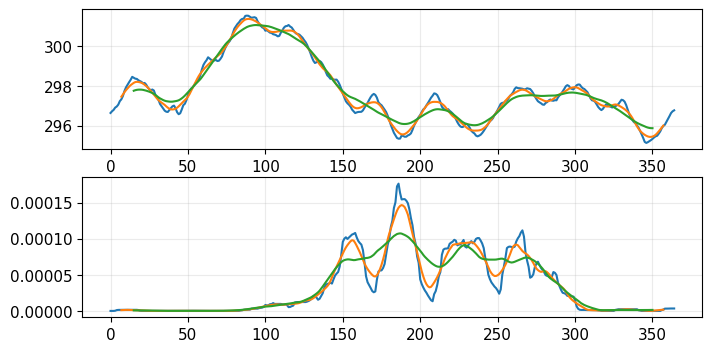

In [2]:
tas = xr.open_dataset('/Users/jacopograssi/Documents/XSeas/working_folder/data/ERA5/2m_temperature/final.nc')
pr = xr.open_dataset('/Users/jacopograssi/Documents/XSeas/working_folder/data/ERA5/total_precipitation/final.nc')

tas_a = tas.isel(lat=10, lon=10)['2t'].sel(time='2000')
pr_a = pr.isel(lat=10, lon=10)['tp'].sel(time='2000')


fig,ax = plt.subplots(2,1, figsize=(8, 4))

ax[0].plot(tas_a.values)
ax[0].plot(tas_a.rolling(time=15, center=True).mean().values)
ax[0].plot(tas_a.rolling(time=30, center=True).mean().values)

ax[1].plot(pr_a.values)
ax[1].plot(pr_a.rolling(time=15, center=True).mean().values)
ax[1].plot(pr_a.rolling(time=30, center=True).mean().values)

In [3]:
# Merging the array into a single array
arr = np.array([tas_a.values, pr_a.values]).T
arr_15 = np.array([tas_a.rolling(time=15, center=True).mean().fillna(tas_a.mean().values).values, pr_a.rolling(time=15, center=True).mean().fillna(pr_a.mean().values).values]).T
arr_30 = np.array([tas_a.rolling(time=30, center=True).mean().fillna(tas_a.mean().values).values, pr_a.rolling(time=30, center=True).mean().fillna(pr_a.mean().values).values]).T

# Normalize the array 
norm_arr = (arr - arr.mean(axis=0)) / arr.std(axis=0)
norm_arr_15 = (arr_15 - arr_15.mean(axis=0)) / arr_15.std(axis=0)
norm_arr_30 = (arr_30 - arr_30.mean(axis=0)) / arr_30.std(axis=0)


models = []

for i, data in enumerate([norm_arr, norm_arr_15, norm_arr_30]):
     model = RCC( data_to_cluster = data,
             n_seas = 4,
             n_iter = 200, 
             min_len= 20, 
             learning_rate= 1,
             starting_bp = [0, 80, 150, 300])
     model.fit()
     models.append(model)

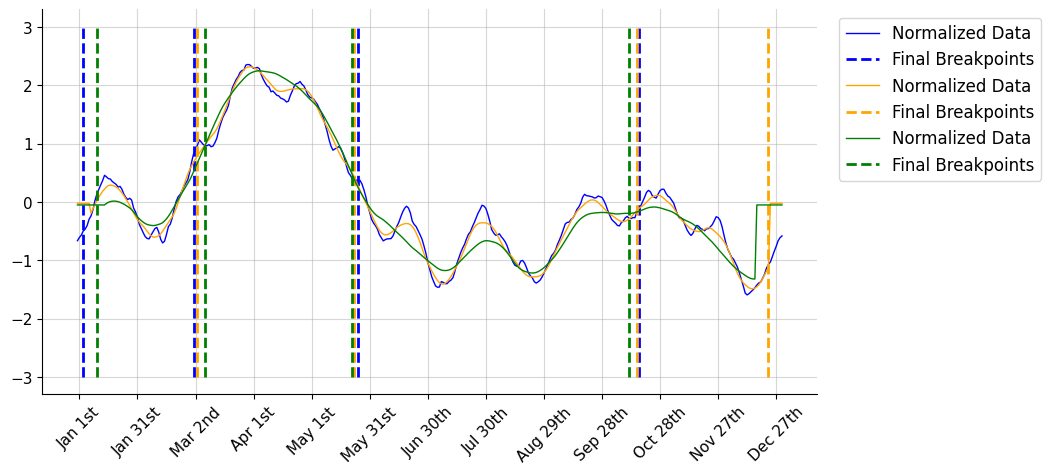

In [4]:
# Plotting the results 
fig, ax = plt.subplots(1, 1, figsize=(10, 5))

for model, norm_arr_plot, color in zip(models, [norm_arr, norm_arr_15, norm_arr_30], ['blue', 'orange', 'green']):

    ax.plot(norm_arr_plot[:,0], lw=1, label='Normalized Data', color=color, alpha=1)
    ax.vlines(model.breakpoints, ymin=-3, ymax=3, color=color, linestyle='--', lw=2, label = 'Final Breakpoints')

    ax.legend(loc='upper right', fontsize=12, bbox_to_anchor=(1.3, 1))
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)
    ax.grid(alpha=0.5)

    lev = np.arange(1,365.,30).tolist();
    ax.set_xticks(lev, labels=[day_of_year_to_date(x) for x in lev], rotation=45);

In [5]:
import numpy as np

def circular_diff(a, b, period=365):
    diff = a - b
    return np.minimum(diff, period - diff)

def match_breakpoints(ref, other, threshold=15, period=365):
    matches = []

    for r in ref:
        dists = circular_diff(r, other, period)
        j = np.argmin(dists)

        if dists[j] <= threshold:
            matches.append((r, other[j], dists[j]))
        else:
            matches.append((r, None, np.nan))

    return matches


matches_15 = match_breakpoints(
    models[0].breakpoints,
    models[1].breakpoints,
    threshold=15
)

matches_30 = match_breakpoints(
    models[0].breakpoints,
    models[2].breakpoints,
    threshold=15
)

breakpoints_diff_30 = np.array([m[2] for m in matches_30])
breakpoints_diff_15 = np.array([m[2] for m in matches_15])
print("Mean difference 15-day:", np.nanmean(breakpoints_diff_15))
print("Mean difference 30-day:", np.nanmean(breakpoints_diff_30))

Mean difference 15-day: -232.5
Mean difference 30-day: -160.5


In [6]:
import numpy as np
import xarray as xr
import matplotlib.pyplot as plt
from xseas import RCC

# -----------------------------
# Settings
# -----------------------------
year = "2000"
period = 365
threshold = 5

n_seas = 4
n_iter = 150
min_len = 50
learning_rate = 1
starting_bp = [0, 80, 150, 300]

# -----------------------------
# Functions
# -----------------------------
def circular_signed_diff(ref, other, period=365):
    """
    Difference other - ref on circular axis.
    Positive = other after ref.
    Negative = other before ref.
    """
    return ((other - ref + period / 2) % period) - period / 2

def match_breakpoints_signed(ref, other, threshold=20, period=365):
    ref = np.asarray(ref)
    other = np.asarray(other)

    matched_signed_diffs = []
    matched_abs_diffs = []
    used = set()

    for r in ref:
        signed_dists = circular_signed_diff(r, other, period)
        abs_dists = np.abs(signed_dists)

        order = np.argsort(abs_dists)

        found = False
        for j in order:
            if j not in used and abs_dists[j] <= threshold:
                matched_signed_diffs.append(signed_dists[j])
                matched_abs_diffs.append(abs_dists[j])
                used.add(j)
                found = True
                break

        if not found:
            matched_signed_diffs.append(np.nan)
            matched_abs_diffs.append(np.nan)

    return np.asarray(matched_signed_diffs), np.asarray(matched_abs_diffs)

def normalize(arr):
    std = arr.std(axis=0)
    std[std == 0] = np.nan
    return (arr - arr.mean(axis=0)) / std

def run_rcc(data):
    model = RCC(
        data_to_cluster=data,
        n_seas=n_seas,
        n_iter=n_iter,
        min_len=min_len,
        learning_rate=learning_rate,
        starting_bp=starting_bp
    )
    model.fit()
    return model

# -----------------------------
# Load data
# -----------------------------
tas = xr.open_dataset(
    "/Users/jacopograssi/Documents/XSeas/working_folder/data/ERA5/2m_temperature/final.nc"
)

pr = xr.open_dataset(
    "/Users/jacopograssi/Documents/XSeas/working_folder/data/ERA5/total_precipitation/final.nc"
)

tas_var = "2t"
pr_var = "tp"

tas_y = tas[tas_var].sel(time=year)
pr_y = pr[pr_var].sel(time=year)

# -----------------------------
# Output arrays
# -----------------------------
shape = (len(tas_y.lat), len(tas_y.lon))

diff_15_vs_0 = np.full(shape, np.nan)
diff_15_vs_30 = np.full(shape, np.nan)

shift_15_vs_0 = np.full(shape, np.nan)
shift_15_vs_30 = np.full(shape, np.nan)

n_matched_15_vs_0 = np.full(shape, np.nan)
n_matched_15_vs_30 = np.full(shape, np.nan)

# -----------------------------
# Spatial loop
# -----------------------------
for iy in range(len(tas_y.lat)):
    print(f"Processing lat {iy + 1}/{len(tas_y.lat)}")

    for ix in range(len(tas_y.lon)):

        try:
            tas_a = tas_y.isel(lat=iy, lon=ix)
            pr_a = pr_y.isel(lat=iy, lon=ix)

            if np.all(np.isnan(tas_a.values)) or np.all(np.isnan(pr_a.values)):
                continue

            arr_0 = np.column_stack([
                tas_a.values,
                pr_a.values
            ])

            arr_15 = np.column_stack([
                tas_a.rolling(time=15, center=True)
                     .mean()
                     .fillna(tas_a.mean())
                     .values,

                pr_a.rolling(time=15, center=True)
                    .mean()
                    .fillna(pr_a.mean())
                    .values
            ])

            arr_30 = np.column_stack([
                tas_a.rolling(time=30, center=True)
                     .mean()
                     .fillna(tas_a.mean())
                     .values,

                pr_a.rolling(time=30, center=True)
                    .mean()
                    .fillna(pr_a.mean())
                    .values
            ])

            norm_0 = normalize(arr_0)
            norm_15 = normalize(arr_15)
            norm_30 = normalize(arr_30)

            if (
                np.any(~np.isfinite(norm_0)) or
                np.any(~np.isfinite(norm_15)) or
                np.any(~np.isfinite(norm_30))
            ):
                continue

            model_0 = run_rcc(norm_0)
            model_15 = run_rcc(norm_15)
            model_30 = run_rcc(norm_30)

            bp_0 = np.asarray(model_0.breakpoints)
            bp_15 = np.asarray(model_15.breakpoints)
            bp_30 = np.asarray(model_30.breakpoints)

            # 15-day rolling is the reference
            signed_diff_0, abs_diff_0 = match_breakpoints_signed(
                ref=bp_15,
                other=bp_0,
                threshold=threshold,
                period=period
            )

            signed_diff_30, abs_diff_30 = match_breakpoints_signed(
                ref=bp_15,
                other=bp_30,
                threshold=threshold,
                period=period
            )

            # Mean absolute difference
            diff_15_vs_0[iy, ix] = np.nanmean(abs_diff_0)
            diff_15_vs_30[iy, ix] = np.nanmean(abs_diff_30)

            # Mean signed shift
            shift_15_vs_0[iy, ix] = np.nanmean(signed_diff_0)
            shift_15_vs_30[iy, ix] = np.nanmean(signed_diff_30)

            # Number of matched breakpoints
            n_matched_15_vs_0[iy, ix] = np.sum(np.isfinite(abs_diff_0))
            n_matched_15_vs_30[iy, ix] = np.sum(np.isfinite(abs_diff_30))

        except Exception:
            continue

# -----------------------------
# Create output dataset
# -----------------------------
ds_out = xr.Dataset(
    {
        "diff_15_vs_0": (
            ["lat", "lon"],
            diff_15_vs_0
        ),
        "diff_15_vs_30": (
            ["lat", "lon"],
            diff_15_vs_30
        ),
        "shift_15_vs_0": (
            ["lat", "lon"],
            shift_15_vs_0
        ),
        "shift_15_vs_30": (
            ["lat", "lon"],
            shift_15_vs_30
        ),
        "n_matched_15_vs_0": (
            ["lat", "lon"],
            n_matched_15_vs_0
        ),
        "n_matched_15_vs_30": (
            ["lat", "lon"],
            n_matched_15_vs_30
        )
    },
    coords={
        "lat": tas_y.lat,
        "lon": tas_y.lon
    }
)

# -----------------------------
# Save output
# -----------------------------
ds_out.to_netcdf("breakpoint_differences_rolling_15_reference_signed.nc")

Processing lat 1/36
Processing lat 2/36
Processing lat 3/36
Processing lat 4/36
Processing lat 5/36
Processing lat 6/36
Processing lat 7/36
Processing lat 8/36
Processing lat 9/36
Processing lat 10/36
Processing lat 11/36
Processing lat 12/36
Processing lat 13/36
Processing lat 14/36
Processing lat 15/36
Processing lat 16/36
Processing lat 17/36
Processing lat 18/36
Processing lat 19/36
Processing lat 20/36
Processing lat 21/36
Processing lat 22/36
Processing lat 23/36
Processing lat 24/36
Processing lat 25/36
Processing lat 26/36
Processing lat 27/36
Processing lat 28/36
Processing lat 29/36
Processing lat 30/36
Processing lat 31/36
Processing lat 32/36
Processing lat 33/36
Processing lat 34/36
Processing lat 35/36
Processing lat 36/36


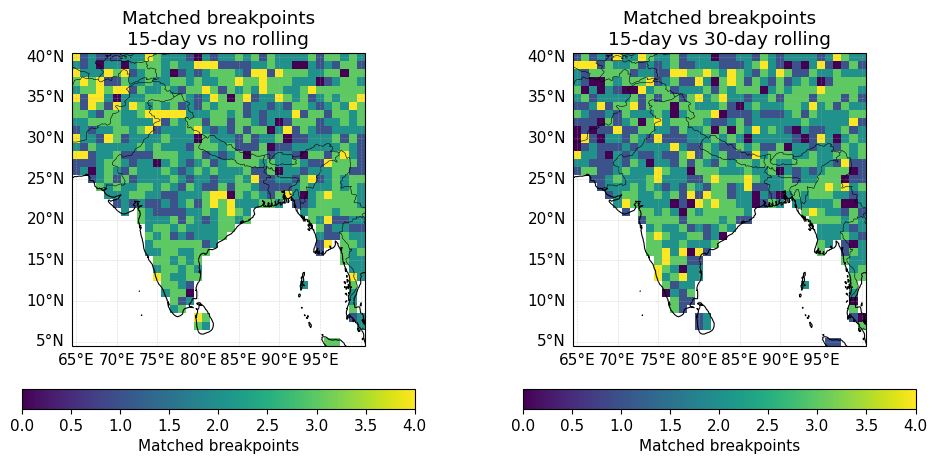

In [7]:
import cartopy.crs as ccrs
import cartopy.feature as cfeature

fig, ax = plt.subplots(
    1, 2,
    figsize=(10, 4.5),
    subplot_kw={"projection": ccrs.PlateCarree()},
    constrained_layout=True
)

plot_kwargs = dict(
    transform=ccrs.PlateCarree(),
    cmap="viridis",
    vmin=0,
    vmax=n_seas,
    cbar_kwargs={
        "label": "Matched breakpoints",
        "orientation": "horizontal",
        "pad": 0.06,
        "shrink": 0.8
    }
)

ds_out["n_matched_15_vs_0"].plot(
    ax=ax[0],
    **plot_kwargs
)

ax[0].set_title("Matched breakpoints\n15-day vs no rolling")

ds_out["n_matched_15_vs_30"].plot(
    ax=ax[1],
    **plot_kwargs
)

ax[1].set_title("Matched breakpoints\n15-day vs 30-day rolling")

for a in ax:
    a.coastlines(linewidth=0.8)
    a.add_feature(cfeature.BORDERS, linewidth=0.4)

    gl = a.gridlines(
        draw_labels=True,
        linewidth=0.4,
        alpha=0.5,
        linestyle="--"
    )
    gl.top_labels = False
    gl.right_labels = False

plt.show()

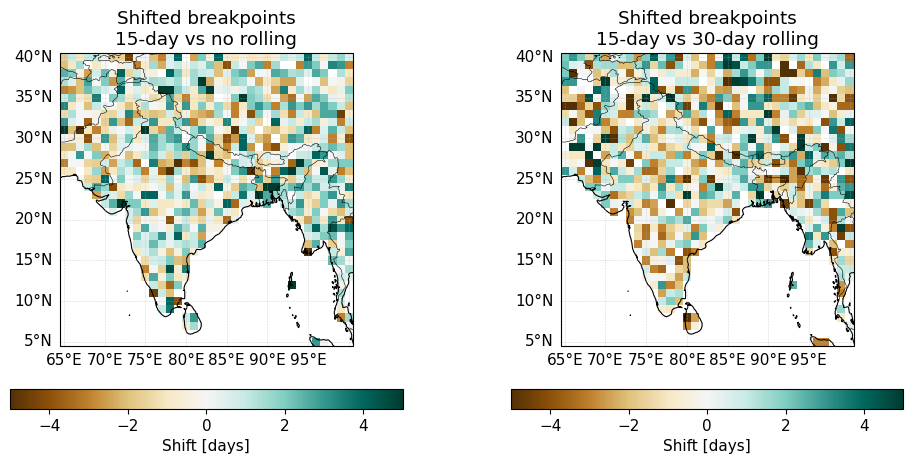

In [16]:
import cartopy.crs as ccrs
import cartopy.feature as cfeature

fig, ax = plt.subplots(
    1, 2,
    figsize=(10, 4.5),
    subplot_kw={"projection": ccrs.PlateCarree()},
    constrained_layout=True
)

plot_kwargs = dict(
    transform=ccrs.PlateCarree(),
    cmap="BrBG",
    vmin=-5,
    vmax=5,
    cbar_kwargs={
        "label": "Shift [days]",
        "orientation": "horizontal",
        "pad": 0.06,
        "shrink": 0.8
    }
)

ds_out["shift_15_vs_0"].plot(
    ax=ax[0],
    **plot_kwargs
)

ax[0].set_title("Shifted breakpoints\n15-day vs no rolling")

ds_out["shift_15_vs_30"].plot(
    ax=ax[1],
    **plot_kwargs
)

ax[1].set_title("Shifted breakpoints\n15-day vs 30-day rolling")

for a in ax:
    a.coastlines(linewidth=0.8)
    a.add_feature(cfeature.BORDERS, linewidth=0.4)

    gl = a.gridlines(
        draw_labels=True,
        linewidth=0.4,
        alpha=0.5,
        linestyle="--"
    )
    gl.top_labels = False
    gl.right_labels = False

plt.show()

In [11]:
ds_out["shift_15_vs_30"].mean()

<xarray.DataArray 'shift_15_vs_30' ()> Size: 8B
array(-0.21880397)
Coordinates:
    spatial_ref  int64 8B 0

In [12]:
ds_out["shift_15_vs_0"].mean()

<xarray.DataArray 'shift_15_vs_0' ()> Size: 8B
array(0.2383479)
Coordinates:
    spatial_ref  int64 8B 0